Import Libraries

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
import joblib
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


Load Dataset

In [2]:
# Load the dataset
df = pd.read_csv('../data/zambia_climate_30yr.csv')
df['Date'] = pd.to_datetime(df['Date'])

print(f"Dataset loaded: {len(df):,} records")
print(f"Features: {df.columns.tolist()}")

Dataset loaded: 109,590 records
Features: ['Date', 'City', 'Latitude', 'Longitude', 'Elevation_m', 'Rainfall_mm', 'Temp_C', 'Soil_Moisture_Pct', 'River_Level_m', 'Year', 'Month', 'DayOfYear', 'Rainfall_7d_avg', 'Rainfall_30d_avg', 'Rainfall_90d_avg', 'Drought_Event', 'Flood_Event']


Feature Engineering - Base Features

In [3]:
# Select features for modeling
feature_columns = [
    'Rainfall_mm',           # Current rainfall
    'Temp_C',                # Current temperature
    'Soil_Moisture_Pct',     # Current soil moisture
    'Month',                 # Seasonality
    'Rainfall_30d_avg',      # Short-term trend
    'Rainfall_90d_avg'       # Long-term trend
]

print(f"Base features: {len(feature_columns)}")
print(feature_columns)

Base features: 6
['Rainfall_mm', 'Temp_C', 'Soil_Moisture_Pct', 'Month', 'Rainfall_30d_avg', 'Rainfall_90d_avg']


Create Lag Features

In [4]:
# Create lag features for better prediction
def create_lag_features(df, city_name):
    city_data = df[df['City'] == city_name].copy()
    city_data = city_data.sort_values('Date')
    
    # Add lag features (previous days)
    for lag in [1, 3, 7]:
        city_data[f'Rainfall_lag_{lag}'] = city_data['Rainfall_mm'].shift(lag)
        city_data[f'Temp_lag_{lag}'] = city_data['Temp_C'].shift(lag)
        city_data[f'Soil_lag_{lag}'] = city_data['Soil_Moisture_Pct'].shift(lag)
    
    return city_data

# Apply to all cities
dfs_with_lags = []
for city in df['City'].unique():
    city_df = create_lag_features(df, city)
    dfs_with_lags.append(city_df)

df_lagged = pd.concat(dfs_with_lags, ignore_index=True)
df_lagged = df_lagged.dropna()  # Remove rows with NaN from lag features

print(f"Data with lag features: {len(df_lagged):,} records")
print(f"New features: {[col for col in df_lagged.columns if 'lag' in col]}")

Data with lag features: 109,520 records
New features: ['Rainfall_lag_1', 'Temp_lag_1', 'Soil_lag_1', 'Rainfall_lag_3', 'Temp_lag_3', 'Soil_lag_3', 'Rainfall_lag_7', 'Temp_lag_7', 'Soil_lag_7']


Update Feature List

In [5]:
# Update feature list with lag features
feature_columns_lagged = feature_columns + [
    'Rainfall_lag_1', 'Rainfall_lag_3', 'Rainfall_lag_7',
    'Temp_lag_1', 'Temp_lag_3', 'Temp_lag_7',
    'Soil_lag_1', 'Soil_lag_3', 'Soil_lag_7'
]

print(f"Total features: {len(feature_columns_lagged)}")
print(f"Features: {feature_columns_lagged}")

Total features: 15
Features: ['Rainfall_mm', 'Temp_C', 'Soil_Moisture_Pct', 'Month', 'Rainfall_30d_avg', 'Rainfall_90d_avg', 'Rainfall_lag_1', 'Rainfall_lag_3', 'Rainfall_lag_7', 'Temp_lag_1', 'Temp_lag_3', 'Temp_lag_7', 'Soil_lag_1', 'Soil_lag_3', 'Soil_lag_7']


Prepare Data for Modeling

In [6]:
# Prepare features and targets
X = df_lagged[feature_columns_lagged].values
y_flood = df_lagged['Flood_Event'].values
y_drought = df_lagged['Drought_Event'].values

# Split data
X_train, X_test, y_train_flood, y_test_flood = train_test_split(
    X, y_flood, test_size=0.2, random_state=42, stratify=y_flood
)

X_train, X_test, y_train_drought, y_test_drought = train_test_split(
    X, y_drought, test_size=0.2, random_state=42, stratify=y_drought
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set size: {len(X_train):,}")
print(f"Test set size: {len(X_test):,}")
print(f"\nFlood events in training: {y_train_flood.sum():,} ({y_train_flood.mean()*100:.2f}%)")
print(f"Drought events in training: {y_train_drought.sum():,} ({y_train_drought.mean()*100:.2f}%)")

Training set size: 87,616
Test set size: 21,904

Flood events in training: 329 (0.38%)
Drought events in training: 29,550 (33.73%)


Train Flood Prediction Model

In [7]:
# Train XGBoost for flood prediction
flood_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    scale_pos_weight=len(y_train_flood[y_train_flood==0]) / len(y_train_flood[y_train_flood==1]),
    use_label_encoder=False,
    eval_metric='logloss'
)

print("Training flood prediction model...")
flood_model.fit(X_train_scaled, y_train_flood)
print("✅ Flood model training complete!")

Training flood prediction model...
✅ Flood model training complete!


Evaluate Flood Model

In [8]:
# Evaluate flood model
y_pred_flood = flood_model.predict(X_test_scaled)
y_pred_proba_flood = flood_model.predict_proba(X_test_scaled)[:, 1]

print("="*60)
print("FLOOD PREDICTION MODEL PERFORMANCE")
print("="*60)
print(f"\nAccuracy: {accuracy_score(y_test_flood, y_pred_flood):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test_flood, y_pred_proba_flood):.4f}")

print("\nClassification Report:")
print(classification_report(y_test_flood, y_pred_flood, target_names=['No Flood', 'Flood']))

print("\nConfusion Matrix:")
cm_flood = confusion_matrix(y_test_flood, y_pred_flood)
print(cm_flood)

FLOOD PREDICTION MODEL PERFORMANCE

Accuracy: 0.9077
ROC-AUC: 0.4923

Classification Report:
              precision    recall  f1-score   support

    No Flood       1.00      0.91      0.95     21822
       Flood       0.01      0.12      0.01        82

    accuracy                           0.91     21904
   macro avg       0.50      0.52      0.48     21904
weighted avg       0.99      0.91      0.95     21904


Confusion Matrix:
[[19873  1949]
 [   72    10]]


Visualize Flood Model Results

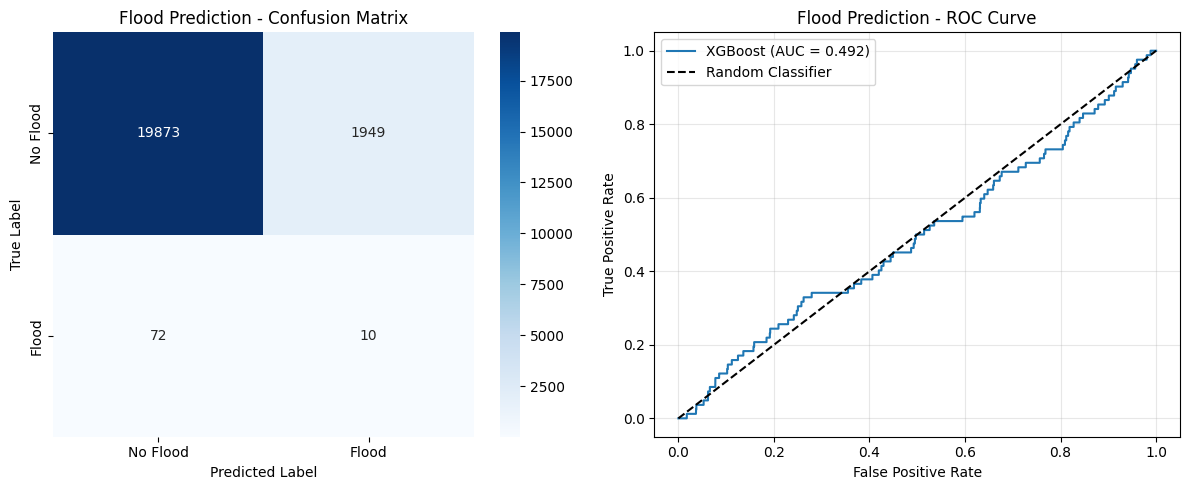

In [9]:
# Visualize flood model results
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Confusion matrix heatmap
sns.heatmap(cm_flood, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Flood', 'Flood'], yticklabels=['No Flood', 'Flood'])
axes[0].set_title('Flood Prediction - Confusion Matrix', fontsize=12)
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test_flood, y_pred_proba_flood)
axes[1].plot(fpr, tpr, label=f'XGBoost (AUC = {roc_auc_score(y_test_flood, y_pred_proba_flood):.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', label='Random Classifier')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Flood Prediction - ROC Curve', fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Flood Model Feature Importance

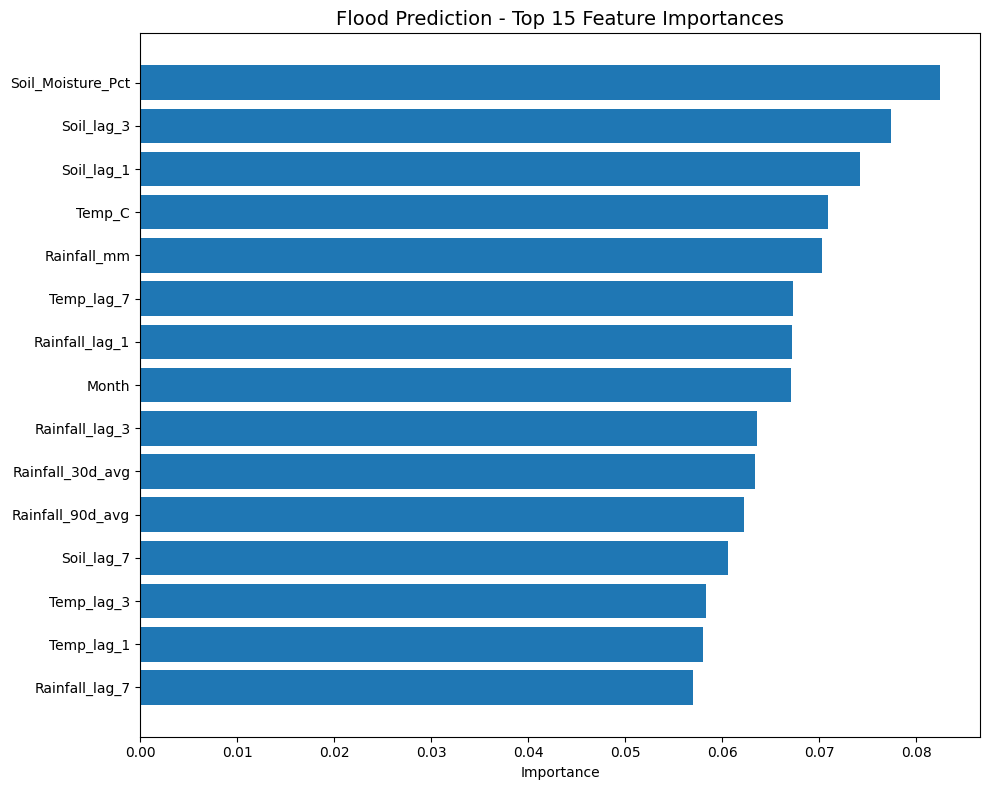

Top 5 features for flood prediction:
              feature  importance
2   Soil_Moisture_Pct    0.082444
13         Soil_lag_3    0.077378
12         Soil_lag_1    0.074206
1              Temp_C    0.070930
0         Rainfall_mm    0.070295


In [10]:
# Feature importance for flood prediction
feature_importance_flood = pd.DataFrame({
    'feature': feature_columns_lagged,
    'importance': flood_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 8))
plt.barh(feature_importance_flood['feature'][:15], feature_importance_flood['importance'][:15])
plt.xlabel('Importance')
plt.title('Flood Prediction - Top 15 Feature Importances', fontsize=14)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("Top 5 features for flood prediction:")
print(feature_importance_flood.head())

Train Drought Prediction Model

In [11]:
# Train XGBoost for drought prediction
drought_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    scale_pos_weight=len(y_train_drought[y_train_drought==0]) / len(y_train_drought[y_train_drought==1]),
    use_label_encoder=False,
    eval_metric='logloss'
)

print("Training drought prediction model...")
drought_model.fit(X_train_scaled, y_train_drought)
print("✅ Drought model training complete!")

Training drought prediction model...
✅ Drought model training complete!


Evaluate Drought Model

In [12]:
# Evaluate drought model
y_pred_drought = drought_model.predict(X_test_scaled)
y_pred_proba_drought = drought_model.predict_proba(X_test_scaled)[:, 1]

print("="*60)
print("DROUGHT PREDICTION MODEL PERFORMANCE")
print("="*60)
print(f"\nAccuracy: {accuracy_score(y_test_drought, y_pred_drought):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test_drought, y_pred_proba_drought):.4f}")

print("\nClassification Report:")
print(classification_report(y_test_drought, y_pred_drought, target_names=['No Drought', 'Drought']))

print("\nConfusion Matrix:")
cm_drought = confusion_matrix(y_test_drought, y_pred_drought)
print(cm_drought)

DROUGHT PREDICTION MODEL PERFORMANCE

Accuracy: 0.9987
ROC-AUC: 1.0000

Classification Report:
              precision    recall  f1-score   support

  No Drought       1.00      1.00      1.00     14516
     Drought       1.00      1.00      1.00      7388

    accuracy                           1.00     21904
   macro avg       1.00      1.00      1.00     21904
weighted avg       1.00      1.00      1.00     21904


Confusion Matrix:
[[14492    24]
 [    5  7383]]


Visualize Drought Model Results

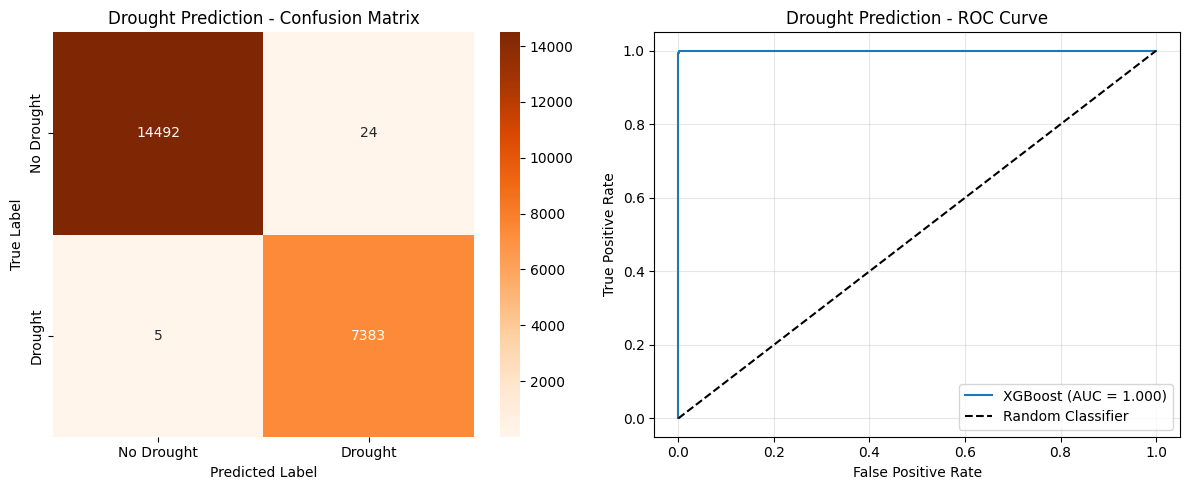

In [13]:
# Visualize drought model results
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Confusion matrix heatmap
sns.heatmap(cm_drought, annot=True, fmt='d', cmap='Oranges', ax=axes[0],
            xticklabels=['No Drought', 'Drought'], yticklabels=['No Drought', 'Drought'])
axes[0].set_title('Drought Prediction - Confusion Matrix', fontsize=12)
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test_drought, y_pred_proba_drought)
axes[1].plot(fpr, tpr, label=f'XGBoost (AUC = {roc_auc_score(y_test_drought, y_pred_proba_drought):.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', label='Random Classifier')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Drought Prediction - ROC Curve', fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Drought Model Feature Importance

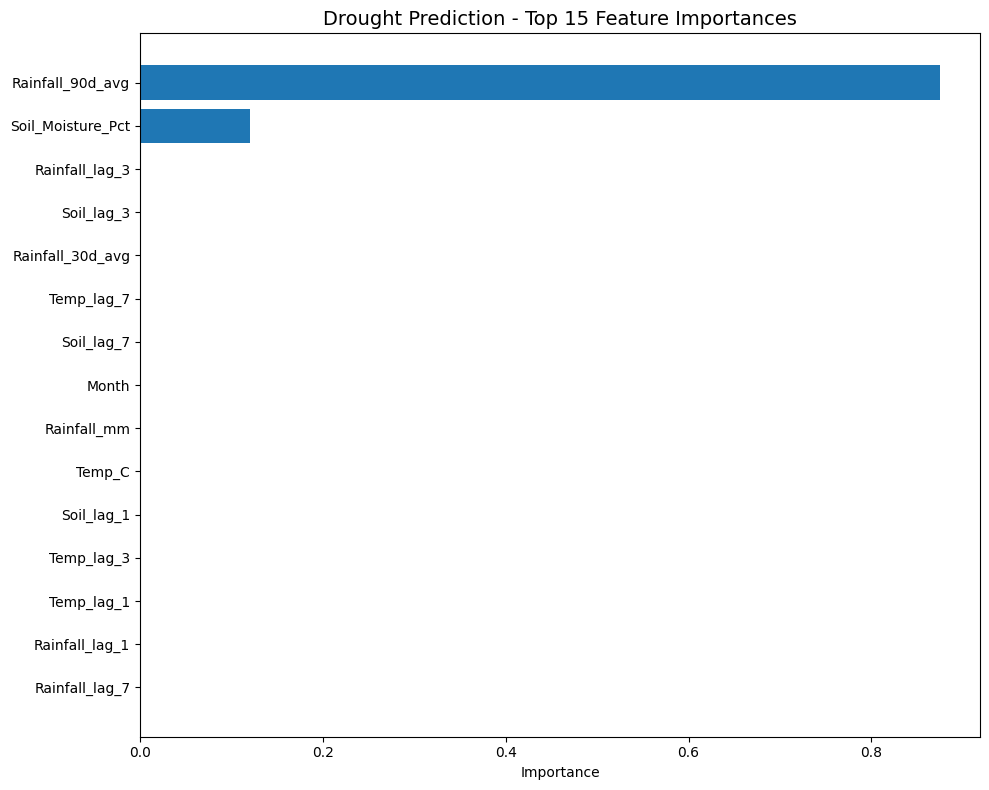

Top 5 features for drought prediction:
              feature  importance
5    Rainfall_90d_avg    0.875006
2   Soil_Moisture_Pct    0.119860
7      Rainfall_lag_3    0.000608
13         Soil_lag_3    0.000498
4    Rainfall_30d_avg    0.000476


In [14]:
# Feature importance for drought prediction
feature_importance_drought = pd.DataFrame({
    'feature': feature_columns_lagged,
    'importance': drought_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 8))
plt.barh(feature_importance_drought['feature'][:15], feature_importance_drought['importance'][:15])
plt.xlabel('Importance')
plt.title('Drought Prediction - Top 15 Feature Importances', fontsize=14)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("Top 5 features for drought prediction:")
print(feature_importance_drought.head())

Model Comparison

In [15]:
# Compare different algorithms
models = {
    'XGBoost': XGBClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'Logistic Regression': LogisticRegression(random_state=42)
}

flood_results = []
drought_results = []

for name, model in models.items():
    # Flood
    if name == 'XGBoost':
        model_flood = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
    else:
        model_flood = model
    
    model_flood.fit(X_train_scaled, y_train_flood)
    flood_score = roc_auc_score(y_test_flood, model_flood.predict_proba(X_test_scaled)[:, 1])
    flood_results.append({'Model': name, 'Flood AUC': flood_score})
    
    # Drought
    if name == 'XGBoost':
        model_drought = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
    else:
        model_drought = model
    
    model_drought.fit(X_train_scaled, y_train_drought)
    drought_score = roc_auc_score(y_test_drought, model_drought.predict_proba(X_test_scaled)[:, 1])
    drought_results.append({'Model': name, 'Drought AUC': drought_score})

# Combine results
comparison_df = pd.DataFrame(flood_results)
comparison_df['Drought AUC'] = [r['Drought AUC'] for r in drought_results]
comparison_df = comparison_df.sort_values('Flood AUC', ascending=False)

print("="*60)
print("MODEL COMPARISON (ROC-AUC Scores)")
print("="*60)
print(comparison_df.to_string(index=False))

MODEL COMPARISON (ROC-AUC Scores)
              Model  Flood AUC  Drought AUC
      Random Forest   0.530510     1.000000
  Gradient Boosting   0.492424     1.000000
            XGBoost   0.482252     0.999994
Logistic Regression   0.454835     0.999761


Save Models

In [16]:
# Create models directory if it doesn't exist
import os
os.makedirs('../models', exist_ok=True)

# Save models and scaler
joblib.dump(flood_model, '../models/flood_model.pkl')
joblib.dump(drought_model, '../models/drought_model.pkl')
joblib.dump(scaler, '../models/scaler.pkl')

print("✅ Models saved successfully!")
print(f"  - Flood model: ../models/flood_model.pkl")
print(f"  - Drought model: ../models/drought_model.pkl")
print(f"  - Scaler: ../models/scaler.pkl")

✅ Models saved successfully!
  - Flood model: ../models/flood_model.pkl
  - Drought model: ../models/drought_model.pkl
  - Scaler: ../models/scaler.pkl


Test Prediction Example

In [17]:
# Test prediction example
test_city = 'Lusaka'
test_data = df[df['City'] == test_city].iloc[-1:]

# Prepare features with lags (simplified for demo)
test_features = np.array([[
    test_data['Rainfall_mm'].values[0],
    test_data['Temp_C'].values[0],
    test_data['Soil_Moisture_Pct'].values[0],
    test_data['Month'].values[0],
    test_data['Rainfall_30d_avg'].values[0],
    test_data['Rainfall_90d_avg'].values[0],
    test_data['Rainfall_mm'].values[0],  # lag 1 (simplified)
    test_data['Rainfall_mm'].values[0],  # lag 3
    test_data['Rainfall_mm'].values[0],  # lag 7
    test_data['Temp_C'].values[0],       # temp lag 1
    test_data['Temp_C'].values[0],       # temp lag 3
    test_data['Temp_C'].values[0],       # temp lag 7
    test_data['Soil_Moisture_Pct'].values[0],  # soil lag 1
    test_data['Soil_Moisture_Pct'].values[0],  # soil lag 3
    test_data['Soil_Moisture_Pct'].values[0]   # soil lag 7
]])
test_scaled = scaler.transform(test_features)

# Predict
flood_prob = flood_model.predict_proba(test_scaled)[0][1]
drought_prob = drought_model.predict_proba(test_scaled)[0][1]

print("="*60)
print(f"PREDICTION FOR {test_city} - {test_data['Date'].values[0]}")
print("="*60)
print(f"Flood Risk: {flood_prob:.1%}")
print(f"Drought Risk: {drought_prob:.1%}")
print(f"\nStatus:")
if flood_prob > 0.7:
    print("  ⚠️ HIGH FLOOD RISK - Immediate attention required")
elif flood_prob > 0.4:
    print

PREDICTION FOR Lusaka - 2026-01-01T00:00:00.000000
Flood Risk: 20.6%
Drought Risk: 0.0%

Status:
